# Prosperity Round 1 Data Analysis
This notebook visualizes the price and trade movements for **ASH_COATED_OSMIUM** and **INTARIAN_PEPPER_ROOT** across three days of market data.

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import glob
import os

# Constants
DAY_OFFSET = 1000000
DATA_DIR = "ROUND_1"

## 1. Data Loading & Preprocessing
We load data from days -2, -1, and 0, concatenating them into a single timeline by offsetting the timestamps.

In [18]:
def load_round_data(base_path):
    all_prices = []
    all_trades = []
    
    days = [-2, -1, 0]
    
    for i, day in enumerate(days):
        # Load Prices
        price_file = os.path.join(base_path, f"prices_round_1_day_{day}.csv")
        if os.path.exists(price_file):
            df_p = pd.read_csv(price_file, sep=";")
            df_p['absolute_timestamp'] = df_p['timestamp'] + (i * DAY_OFFSET)
            all_prices.append(df_p)
            
        # Load Trades
        trade_file = os.path.join(base_path, f"trades_round_1_day_{day}.csv")
        if os.path.exists(trade_file):
            df_t = pd.read_csv(trade_file, sep=";")
            df_t['absolute_timestamp'] = df_t['timestamp'] + (i * DAY_OFFSET)
            df_t['day'] = day
            all_trades.append(df_t)
            
    prices_df = pd.concat(all_prices, ignore_index=True)
    trades_df = pd.concat(all_trades, ignore_index=True)
    
    return prices_df, trades_df

# Load the data
prices, trades = load_round_data("ROUND_1")
prices['mid_price'] = prices['mid_price'].replace(0, np.nan)
print(f"Loaded {len(prices)} price points and {len(trades)} trades.")

Loaded 60000 price points and 2276 trades.


## 2. Interactive Visualization
The following function creates an interactive plot for a specific product, showing mid-price, bid/ask spreads, and trade execution points.

In [19]:
def visualize_product(product_name, prices_df, trades_df, y_start=None, y_end=None, regression=False, sma_window=None):
    p_df = prices_df[prices_df['product'] == product_name].sort_values('absolute_timestamp')
    t_df = trades_df[trades_df['symbol'] == product_name].sort_values('absolute_timestamp')
    
    fig = go.Figure()

    # 1. Bid/Ask Shading (Spread)
    fig.add_trace(go.Scatter(
        x=pd.concat([p_df['absolute_timestamp'], p_df['absolute_timestamp'][::-1]]),
        y=pd.concat([p_df['ask_price_1'], p_df['bid_price_1'][::-1]]),
        fill='toself',
        fillcolor='rgba(100, 100, 100, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='Spread (Ask1-Bid1)'
    ))

    # 2. Mid Price Line
    fig.add_trace(go.Scatter(
        x=p_df['absolute_timestamp'],
        y=p_df['mid_price'],
        mode='lines',
        name='Mid Price',
        line=dict(color='#1f77b4', width=2)
    ))
    
    # 3. Linear Regression Overlay
    if regression:
        x = p_df['absolute_timestamp']
        y = p_df['mid_price']
        m, b = np.polyfit(x, y, 1)
        reg_line = m * x + b
        fig.add_trace(go.Scatter(x=x, y=reg_line, mode='lines', name=f'Trend (slope={m:.4f})', 
                                 line=dict(color='#d62728', width=2, dash='dash')))

    # 4. Moving Average Overlay
    if sma_window:
        sma = p_df['mid_price'].rolling(window=sma_window).mean()
        fig.add_trace(go.Scatter(x=p_df['absolute_timestamp'], y=sma, mode='lines', name=f'{sma_window}-Tick SMA', 
                                 line=dict(color='#bcbd22', width=2)))

    # 5. Trades Scatter
    if not t_df.empty:
        fig.add_trace(go.Scatter(
            x=t_df['absolute_timestamp'],
            y=t_df['price'],
            mode='markers',
            name='Trades',
            marker=dict(size=6, color='#ff7f0e', symbol='diamond', line=dict(width=1, color='white')),
            text=t_df['quantity'].apply(lambda q: f"Qty: {q}")
        ))

    fig.update_layout(
        title=f"Market Analysis: {product_name}",
        xaxis_title="Timestamp",
        yaxis_title="Price",
        template="plotly_dark",
        hovermode="x unified",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    
    for i in range(1, 3):
        fig.add_vline(x=i * DAY_OFFSET, line_dash="dash", line_color="gray", annotation_text=f"Day {i-2} -> {i-1}")
    
    if y_start is not None and y_end is not None:
        fig.update_yaxes(range=[y_start, y_end])

    return fig


In [20]:

products = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']

visualize_product('INTARIAN_PEPPER_ROOT', prices, trades, 9900, 13000).show()
visualize_product('ASH_COATED_OSMIUM', prices, trades, 9950, 10050).show()

## 3. Key Statistics
A quick summary of volatility and volume for each ticker.

In [21]:
stats = []
for product in prices['product'].unique():
    p_df = prices[prices['product'] == product]
    t_df = trades[trades['symbol'] == product]
    
    stats.append({
        'Product': product,
        'Avg Mid Price': p_df['mid_price'].mean(),
        'Std Dev': p_df['mid_price'].std(),
        'Avg Spread': (p_df['ask_price_1'] - p_df['bid_price_1']).mean(),
        'Total Trade Volume': t_df['quantity'].sum(),
        'Trade Count': len(t_df)
    })

pd.DataFrame(stats).set_index('Product')

,Avg Mid Price,Std Dev,Avg Spread,Total Trade Volume,Trade Count
Product,,,,,
INTARIAN_PEPPER_ROOT,11499.888549,866.107144,13.046699,5230,1011
ASH_COATED_OSMIUM,10000.204234,5.349695,16.175228,6593,1265


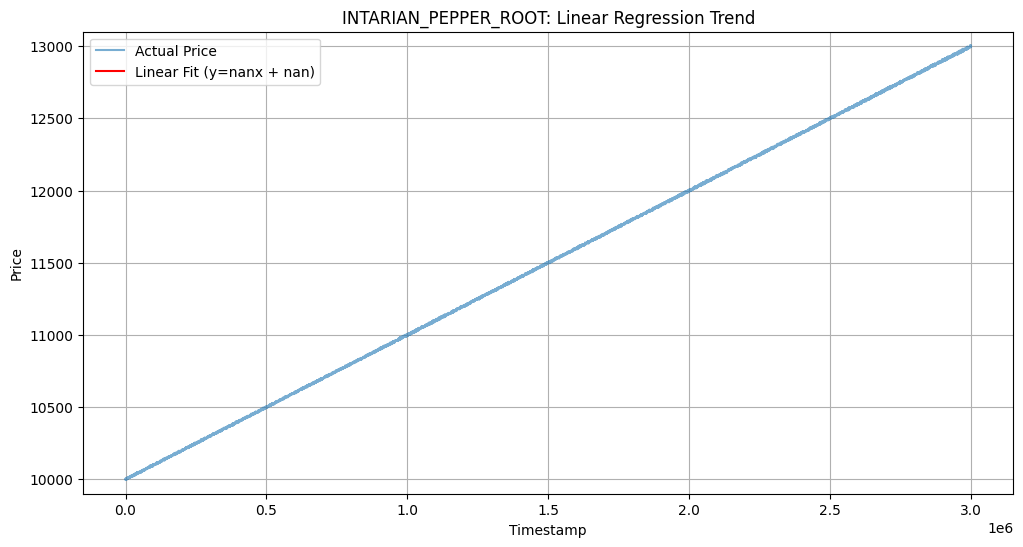

In [22]:
import matplotlib.pyplot as plt

# Filter data for Pepper Root
pepper_df = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT']
x = pepper_df['absolute_timestamp']
y = pepper_df['mid_price']

# Perform Linear Regression
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Actual Price', alpha=0.6)
plt.plot(x, m*x + b, color='red', label=f'Linear Fit (y={m:.4f}x + {b:.2f})')
plt.title('INTARIAN_PEPPER_ROOT: Linear Regression Trend')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.ylim(9900, 13100)
plt.legend()
plt.grid(True)
plt.show()


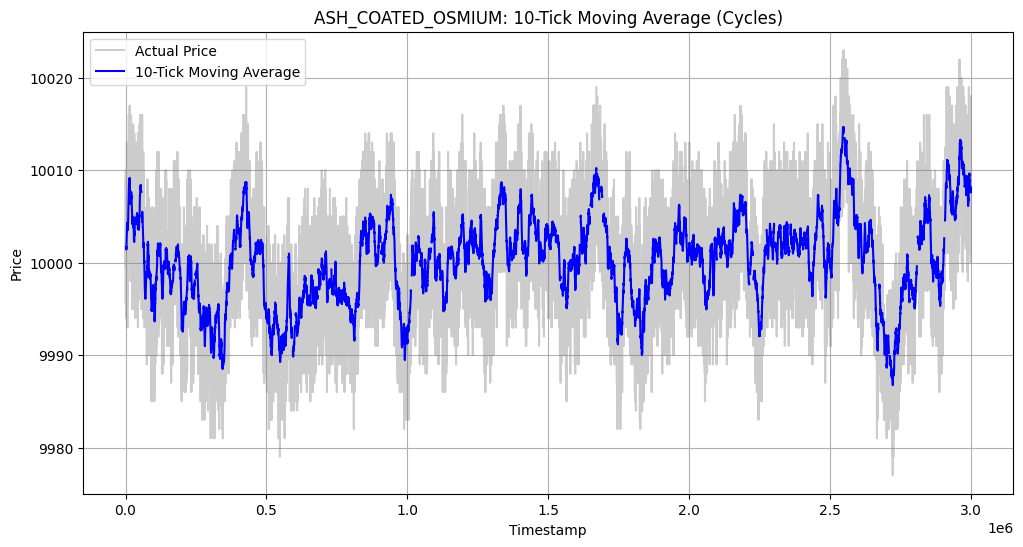

In [26]:
# Filter data for Osmium
osmium_df = prices[prices['product'] == 'ASH_COATED_OSMIUM']
x = osmium_df['absolute_timestamp']
y = osmium_df['mid_price']

# Calculate 10-tick Moving Average
ma10 = y.rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Actual Price', alpha=0.4, color='gray')
plt.plot(x, ma10, label='10-Tick Moving Average', color='blue')
plt.title('ASH_COATED_OSMIUM: 10-Tick Moving Average (Cycles)')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.ylim(9975, 10025)
plt.legend()
plt.grid(True)
plt.show()
